# PD Model Training - XGBoost (LoanStats3a, best-practice tuning)

**Purpose:** Train a classical PD model on **LoanStats3a**-derived features from **01_pd_lendingclub_feature_engineering.ipynb**. We use **Optuna** (Bayesian-style hyperparameter search), **stratified 5-fold CV**, and **early stopping** to maximize AUC-ROC; then refit on full data and save for `eval_runner` and proof generation (comparable to quantum models).

**Runs locally, on Google Colab, or on Kaggle.** No API keys or Colab Secrets are required (XGBoost is fully offline). On Colab, use **Runtime -> Change runtime type -> T4 GPU** to speed up Optuna tuning (~2-5%— faster than CPU).

**Input:** `data/credit_risk_pd/LendingClub/processed/lendingclub_engineered.parquet` (from notebook 01; on Colab, run section "Setup: Colab vs local" first so the repo and data are available).

**Output:** Trained model saved to `models/pd/pd_model_local_v2.pkl`; metrics: AUC-ROC, F1, Precision, Recall. Ready for sample-by-sample evaluation (`eval_runner` prefers v2).

**Why our AUC may be lower than some other Lending Club notebooks:** We use **out-of-time evaluation** (train up to 2015, val 2016, test 2017-2018), which is harder than a random train/test split. We also **exclude leakage features**: we do not use Lending Club's own risk labels (`grade`, `sub_grade`, `int_rate`) as inputs, so the model predicts default from applicant and loan features only. Notebooks that include those LC-assigned fields can report higher AUC (e.g. ~0.73+); ours is a fairer estimate for a model that does not use LC's internal grading.

**Tip (local):** Run from the repo root folder. Use **Kernel -> Select Kernel** and pick the environment where you installed `pandas`, `xgboost`, `scikit-learn`, `optuna`.

### Install packages into this kernel's environment
Run the cell below once to see **which Python** this notebook uses. Then in a terminal (PowerShell or Bash), run:
```
<that path> -m pip install -r requirements-notebooks.txt
```
from the repo root (or `notebooks/`). That way `pip` installs into the **same** environment as this kernel.

In [1]:
import sys
print('This notebook kernel is using:')
print(sys.executable)
print()
print('To install packages into THIS environment, run in a terminal:')
print(f'  {sys.executable} -m pip install -r notebooks/requirements-notebooks.txt')
print('(from the repo root, or use a full path to requirements-notebooks.txt)')

This notebook kernel is using:
c:\Users\leemi\AppData\Local\Programs\Python\Python311\python.exe

To install packages into THIS environment, run in a terminal:
  c:\Users\leemi\AppData\Local\Programs\Python\Python311\python.exe -m pip install -r notebooks/requirements-notebooks.txt
(from the repo root, or use a full path to requirements-notebooks.txt)


## Setup: Colab vs local vs Kaggle

Run this cell once. On **Google Colab** it clones the repo (if needed), installs dependencies, and enables **XGBoost GPU** for faster Optuna tuning. When GPU is used we set **max_bin=512** to use more GPU RAM and often speed up; on CPU we run **4 Optuna trials in parallel** to reduce wall-clock time. No API keys or Colab Secrets are required. You still need the engineered data: run **01_pd_lendingclub_feature_engineering.ipynb** first (e.g. after uploading `LoanStats3a.csv` and running it), or upload `lendingclub_engineered.parquet` into `data/credit_risk_pd/LendingClub/processed/`. On a **local** run this cell only sets CPU mode.

In [2]:
import os
import sys
from pathlib import Path

# Detect Colab and Kaggle (or set IN_KAGGLE = True to force Kaggle paths)
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
IN_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None or Path("/kaggle/working").exists()

if IN_COLAB:
    REPO_URL = "https://github.com/leemingloon/ocr-agentic-rag.git"
    REPO_DIR = "ocr-agentic-rag"
    os.environ["COLAB_GPU"] = os.environ.get("COLAB_GPU", "1")
    if os.path.isdir(REPO_DIR):
        get_ipython().run_line_magic("cd", REPO_DIR)
        get_ipython().system("git pull")
    else:
        get_ipython().system(f"git clone {REPO_URL} {REPO_DIR}")
        get_ipython().run_line_magic("cd", REPO_DIR)
    get_ipython().system("pip install -q -r notebooks/requirements-notebooks.txt")
    USE_GPU = os.environ.get("COLAB_GPU", "1") == "1"
    print("Colab: repo ready. XGBoost will use GPU for tuning." if USE_GPU else "Colab: repo ready. Using CPU (set Runtime -> GPU for faster Optuna).")
elif IN_KAGGLE:
    REPO_URL = "https://github.com/leemingloon/ocr-agentic-rag.git"
    REPO_DIR = "ocr-agentic-rag"
    if not (Path("/kaggle/working/ocr-agentic-rag") / "credit_risk").exists():
        get_ipython().system("git clone --depth 1 " + REPO_URL + " " + REPO_DIR)
        get_ipython().run_line_magic("cd", REPO_DIR)
    else:
        get_ipython().run_line_magic("cd", "/kaggle/working/ocr-agentic-rag")
    get_ipython().system("pip install -q -r notebooks/requirements-notebooks.txt")
    USE_GPU = os.environ.get("KAGGLE_GPU_ENABLED", "0") == "1" or "GPU" in os.environ.get("KAGGLE_KERNEL_RUN_TYPE", "")
    print("Kaggle: repo ready. Run 01 first in same session or add lendingclub_engineered.parquet as input.")
else:
    USE_GPU = False
    print("Local run. For faster Optuna, open this notebook in Google Colab or Kaggle and set GPU.")

Local run. For faster Optuna, open this notebook in Google Colab or Kaggle and set GPU.


## 1. Load engineered data and split

In [3]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import os
import random

# Find repo root (works when run from repo root or from notebooks/)
ROOT = Path.cwd()
for _ in range(5):
    if (ROOT / "credit_risk").is_dir() and (ROOT / "data").is_dir():
        break
    ROOT = ROOT.parent
if not (ROOT / "credit_risk").is_dir():
    raise RuntimeError('Repo root not found. Run this notebook from the ocr-agentic-rag folder (or notebooks/ subfolder).')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

from credit_risk.feature_engineering.common_features import get_feature_names_no_leakage_v2
from credit_risk.feature_engineering.feature_screening import screen_features_train_only

DATA_PATH = ROOT / "data" / "credit_risk_pd" / "LendingClub" / "processed" / "lendingclub_engineered.parquet"
if not DATA_PATH.exists() and Path("/kaggle/working").exists():
    for d in Path("/kaggle/input").iterdir():
        cand = d / "lendingclub_engineered.parquet"
        if cand.exists():
            DATA_PATH = cand
            break
if not DATA_PATH.exists():
    raise FileNotFoundError("Run 01_pd_lendingclub_feature_engineering.ipynb first to create lendingclub_engineered.parquet")

df = pd.read_parquet(DATA_PATH)
all_feature_names = get_feature_names_no_leakage_v2()
X = df[[c for c in all_feature_names if c in df.columns]].copy()
y = df["default"]
if X.shape[1] != len(all_feature_names):
    for c in all_feature_names:
        if c not in X.columns:
            X[c] = 0.0
X = X[all_feature_names]

# Time-based (out-of-time) split when val/test have data; else random split
from sklearn.model_selection import train_test_split
use_time_split = False
if "split" in df.columns:
    train_idx = df["split"] == "train"
    val_idx = df["split"] == "val"
    test_idx = df["split"] == "test"
    if val_idx.sum() >= 1 and test_idx.sum() >= 1:
        X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]
        y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]
        use_time_split = True
        print(f"Out-of-time split: Train {X_train.shape[0]:,} / Val {X_val.shape[0]:,} / Test {X_test.shape[0]:,}")
if not use_time_split:
    X_train, X_rest, y_train, y_rest = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, test_size=0.5, random_state=42, stratify=y_rest)
    print(f"Random split (time split had empty val/test or no 'split'): Train {X_train.shape[0]:,} / Val {X_val.shape[0]:,} / Test {X_test.shape[0]:,}")

# Train-only feature screening (missingness -> KS -> correlation pruning)
screening = screen_features_train_only(
    X_train,
    y_train,
    missingness_threshold=0.50,
    min_ks=0.001,
    corr_threshold=0.95,
)
feature_names = screening.selected_features
X_train = X_train[feature_names]
X_val = X_val[feature_names]
X_test = X_test[feature_names]
print(f"Selected {len(feature_names)}/{len(all_feature_names)} features after screening")

Out-of-time split: Train 6,529 / Val 11,536 / Test 21,721
Selected 77/116 features after screening


In [4]:
# HF-style feature dropout: simulate 5-15% missing per column for robustness (HF benchmark)
import random

HF_MISSING_COLS = ["dti_ratio", "dti_to_income", "credit_history_months"]  # Always missing at HF eval
def _apply_hf_dropout(X, p_drop=0.10, hf_missing_p=0.5, seed=42):
    """Randomly set p_drop fraction of values per column to NaN. Extra dropout for HF-missing cols."""
    X_noisy = X.copy()
    rng = random.Random(seed)
    for col in X_noisy.columns:
        n = len(X_noisy)
        p = max(p_drop, hf_missing_p) if col in HF_MISSING_COLS else p_drop
        n_drop = int(n * p)
        if n_drop > 0:
            idx = rng.sample(range(n), n_drop)
            X_noisy.iloc[idx, X_noisy.columns.get_loc(col)] = np.nan
    return X_noisy

P_DROP = 0.10  # 10% NaN per column (HF-style)
X_train_noisy = _apply_hf_dropout(X_train, p_drop=P_DROP, hf_missing_p=0.5, seed=42)
medians = X_train.median().to_dict()
X_train_noisy = X_train_noisy.fillna(medians)
X_train_aug = pd.concat([X_train, X_train_noisy], axis=0, ignore_index=True)
y_train_aug = pd.concat([y_train, y_train], axis=0, ignore_index=True)
X_val_filled = X_val.fillna(medians)
X_test_filled = X_test.fillna(medians)
print(f"HF dropout: train augmented {X_train.shape[0]:,} -> {X_train_aug.shape[0]:,} (clean + {P_DROP*100:.0f}% noisy)")

HF dropout: train augmented 6,529 -> 13,058 (clean + 10% noisy)


## 2. Iterative testing: XGBoost vs Random Forest vs Logistic Regression

Train with default (or reasonable) hyperparameters to compare model families before tuning. Logistic Regression uses StandardScaler so distance/scale-sensitive behavior is comparable.

In [5]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

def eval_binary(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "auc_roc": roc_auc_score(y_true, y_prob),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
    }

results = {}

In [6]:
import xgboost as xgb

scale = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
# GPU on Colab when available; fall back to CPU if XGBoost has no GPU support (e.g. Colab default build)
xgb_kw = {"tree_method": "gpu_hist", "device": "cuda"} if USE_GPU else {"tree_method": "hist"}
if USE_GPU:
    try:
        _t = xgb.XGBClassifier(n_estimators=2, **xgb_kw)
        _t.fit(X_train[:20], y_train[:20])
    except Exception as e:
        if "gpu_hist" in str(e) or "valid values" in str(e):
            USE_GPU = False
            xgb_kw = {"tree_method": "hist"}  # no max_bin needed for CPU
        else:
            raise
model_xgb = xgb.XGBClassifier(
    max_depth=6,
    learning_rate=0.1,
    n_estimators=100,
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=scale,
    random_state=42,
    **xgb_kw,
)
model_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
p_val = model_xgb.predict_proba(X_val)[:, 1]
results["XGBoost"] = eval_binary(y_val, p_val)
print("XGBoost (default):", results["XGBoost"], f"(n_val={len(y_val)})")

XGBoost (default): {'auc_roc': 0.5749815480473855, 'f1': 0.21873247335950646, 'precision': 0.18759018759018758, 'recall': 0.26227303295225285} (n_val=11536)


In [7]:
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

model_rf = RandomForestClassifier(n_estimators=100, max_depth=12, class_weight="balanced", random_state=42)
model_rf.fit(X_train, y_train)
p_val_rf = model_rf.predict_proba(X_val)[:, 1]
results["RandomForest"] = eval_binary(y_val, p_val_rf)
print("RandomForest (default):", results["RandomForest"], f"(n_val={len(y_val)})")

# LightGBM baseline (same feature set and val split)
lgb_scale = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
lgb_params = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "num_leaves": 31,
    "learning_rate": 0.05,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1,
    "random_state": 42,
    "scale_pos_weight": lgb_scale,
}
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)
lgb_model = lgb.train(lgb_params, lgb_train, num_boost_round=200, valid_sets=[lgb_val])
p_val_lgb = lgb_model.predict(X_val)
results["LightGBM"] = eval_binary(y_val, p_val_lgb)
print("LightGBM (default):", results["LightGBM"], f"(n_val={len(y_val)})")

print("\nComparison:", pd.DataFrame(results).T.round(4).to_string())

RandomForest (default): {'auc_roc': 0.5935644996544505, 'f1': 0.0864461045891142, 'precision': 0.20930232558139536, 'recall': 0.05447209145931405} (n_val=11536)
LightGBM (default): {'auc_roc': 0.6090898711980428, 'f1': 0.2121580547112462, 'precision': 0.19356627842484747, 'recall': 0.2347007397444519} (n_val=11536)

Comparison:               auc_roc      f1  precision  recall
XGBoost        0.5750  0.2187     0.1876  0.2623
RandomForest   0.5936  0.0864     0.2093  0.0545
LightGBM       0.6091  0.2122     0.1936  0.2347


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# LR benefits from scaling ; fit on train, transform val
scaler_lr = StandardScaler()
X_train_scaled = scaler_lr.fit_transform(X_train)
X_val_scaled = scaler_lr.transform(X_val)

model_lr = LogisticRegression(max_iter=500, class_weight="balanced", random_state=42)
model_lr.fit(X_train_scaled, y_train)
p_val_lr = model_lr.predict_proba(X_val_scaled)[:, 1]
results["LogisticRegression"] = eval_binary(y_val, p_val_lr)
print("LogisticRegression (default, scaled):", results["LogisticRegression"], f"(n_val={len(y_val)})")
print("\nComparison (XGBoost, Random Forest, Logistic Regression):")
print(pd.DataFrame(results).T.round(4).to_string())

LogisticRegression (default, scaled): {'auc_roc': 0.6336675240882553, 'f1': 0.2852233676975945, 'precision': 0.19155319639972307, 'recall': 0.5581708137188971} (n_val=11536)

Comparison (XGBoost, Random Forest, Logistic Regression):
                    auc_roc      f1  precision  recall
XGBoost              0.5750  0.2187     0.1876  0.2623
RandomForest         0.5936  0.0864     0.2093  0.0545
LightGBM             0.6091  0.2122     0.1936  0.2347
LogisticRegression   0.6337  0.2852     0.1916  0.5582


## 3. Hyperparameter tuning (XGBoost) - Optuna + stratified K-fold

Best practices for LendingClub/LoanStats3a: **Bayesian-style tuning (Optuna)** with **stratified 5-fold CV** and **early stopping** to maximize AUC-ROC. We search over depth, learning rate, regularization (reg_alpha, reg_lambda, gamma), subsample/colsample, and min_child_weight; then refit the best config on full train+val for the final artifact.

**Colab:** To use more GPU and RAM we run **3 Optuna trials in parallel** and set **max_bin=1024** for `gpu_hist` (more GPU memory per tree, often faster). If you see CUDA or crash, set `OPTUNA_N_JOBS = 1` in the cell below.

In [9]:
import time
import optuna
from sklearn.model_selection import StratifiedKFold

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Tuning config: on Colab GPU use ONE trial at a time to saturate T4 (max_bin 2048 = more GPU work)
N_TRIALS = 50
USE_GPU_FLAG = USE_GPU if "USE_GPU" in dir() else False
# GPU: n_jobs=1 so the single trial keeps the GPU busy; CPU: use 6 parallel trials (e.g. i5-11500)
import os
OPTUNA_N_JOBS = 1 if USE_GPU_FLAG else min(6, (os.cpu_count() or 4) // 2)
tune_start = time.perf_counter()

# GPU: max_bin 2048 and device=cuda to maximize T4 utilization per trial
if USE_GPU_FLAG:
    xgb_common = {"tree_method": "gpu_hist", "device": "cuda", "max_bin": 2048}
else:
    xgb_common = {"tree_method": "hist"}

def objective(trial):
    # HF-robust search space (shallower trees, stronger regularization)
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.02, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 150, 400),
        "min_child_weight": trial.suggest_int("min_child_weight", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.7, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 0.9),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.1, 2.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 2.0),
        "objective": "binary:logistic",
        "scale_pos_weight": scale,
        "eval_metric": "auc",
        "random_state": RANDOM_SEED,
        **xgb_common,
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs = []
    for train_idx, val_idx in skf.split(X_train_aug, y_train_aug):
        X_f, X_v = X_train_aug.iloc[train_idx], X_train_aug.iloc[val_idx]
        y_f, y_v = y_train_aug.iloc[train_idx], y_train_aug.iloc[val_idx]

        clf = xgb.XGBClassifier(**params)
        clf.fit(X_f, y_f, eval_set=[(X_v, y_v)], verbose=False)

        p = clf.predict_proba(X_v)[:, 1]
        aucs.append(roc_auc_score(y_v, p))
    return np.mean(aucs)

from optuna.samplers import TPESampler
sampler = TPESampler(seed=RANDOM_SEED, n_startup_trials=10)
study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
)
study.optimize(objective, n_trials=N_TRIALS, n_jobs=OPTUNA_N_JOBS, show_progress_bar=False)
tune_elapsed = time.perf_counter() - tune_start

best_params = {k: v for k, v in study.best_params.items()
               if k in ["max_depth","learning_rate","n_estimators",
                        "min_child_weight","subsample","colsample_bytree",
                        "reg_alpha","reg_lambda"]}
best_params.update({
    "objective": "binary:logistic",
    "scale_pos_weight": scale,
    "eval_metric": "auc",
    "random_state": RANDOM_SEED,
    **xgb_common,
})
print("Best params:", best_params)
print("Best CV AUC:", round(float(study.best_value), 4), f"(n_train={len(X_train_aug)}, folds=5)")
print("Tuning time: {:.1f}s ({:.1f}s per trial)".format(tune_elapsed, tune_elapsed / max(N_TRIALS, 1)))

Best params: {'max_depth': 6, 'learning_rate': 0.014993029606520929, 'n_estimators': 399, 'min_child_weight': 5, 'subsample': 0.8684234161481916, 'colsample_bytree': 0.838189942683847, 'reg_alpha': 0.2621362239319259, 'reg_lambda': 0.37793010204829053, 'objective': 'binary:logistic', 'scale_pos_weight': np.float64(6.3690744920993225), 'eval_metric': 'auc', 'random_state': 42, 'tree_method': 'hist'}
Best CV AUC: 0.8248 (n_train=13058, folds=5)
Tuning time: 290.9s (5.8s per trial)


## 3b. Hyperparameter tuning (LightGBM) - Optuna + stratified K-fold

Mirror of the XGBoost tuning above, but using **LightGBM** as the base learner. Uses the **same augmented train set** (`X_train_aug`, `y_train_aug`), **stratified 5-fold CV**, and the same Optuna budget (`N_TRIALS`, `RANDOM_SEED`). This lets us compare tuned LightGBM vs tuned XGBoost on the same folds and sample size.

In [10]:
import lightgbm as lgb

lgb_tune_start = time.perf_counter()

# LightGBM uses the same scale_pos_weight and RANDOM_SEED as XGBoost
lgb_scale = scale

def lgb_objective(trial):
    params = {
        "num_leaves": trial.suggest_int("num_leaves", 31, 127),
        "learning_rate": trial.suggest_float("learning_rate_lgb", 0.01, 0.1, log=True),
        "n_estimators": trial.suggest_int("n_estimators_lgb", 150, 400),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 100),
        "subsample": trial.suggest_float("subsample_lgb", 0.7, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree_lgb", 0.7, 0.9),
        "reg_alpha": trial.suggest_float("reg_alpha_lgb", 0.0, 2.0),
        "reg_lambda": trial.suggest_float("reg_lambda_lgb", 0.0, 2.0),
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "random_state": RANDOM_SEED,
        "scale_pos_weight": lgb_scale,
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    aucs = []
    for train_idx, val_idx in skf.split(X_train_aug, y_train_aug):
        X_f, X_v = X_train_aug.iloc[train_idx], X_train_aug.iloc[val_idx]
        y_f, y_v = y_train_aug.iloc[train_idx], y_train_aug.iloc[val_idx]

        dtrain = lgb.Dataset(X_f, label=y_f)
        dval = lgb.Dataset(X_v, label=y_v, reference=dtrain)
        gbm = lgb.train(params, dtrain, num_boost_round=params["n_estimators"], valid_sets=[dval])
        p = gbm.predict(X_v)
        aucs.append(roc_auc_score(y_v, p))
    return float(np.mean(aucs))

lgb_sampler = TPESampler(seed=RANDOM_SEED, n_startup_trials=10)
study_lgb = optuna.create_study(direction="maximize", sampler=lgb_sampler)
study_lgb.optimize(lgb_objective, n_trials=N_TRIALS, n_jobs=OPTUNA_N_JOBS, show_progress_bar=False)

lgb_tune_elapsed = time.perf_counter() - lgb_tune_start
best_lgb_params = study_lgb.best_params.copy()
print("Best LGB params:", best_lgb_params)
print("Best LGB CV AUC:", round(float(study_lgb.best_value), 4), f"(n_train={len(X_train_aug)}, folds=5)")
print("LGB tuning time: {:.1f}s ({:.1f}s per trial)".format(lgb_tune_elapsed, lgb_tune_elapsed / max(N_TRIALS, 1)))

# Fit best LGB model on train_aug for validation comparison
lgb_train_full = lgb.Dataset(X_train_aug, label=y_train_aug)
params_final_lgb = best_lgb_params.copy()
params_final_lgb.update({
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "random_state": RANDOM_SEED,
    "scale_pos_weight": lgb_scale,
})

best_n_estimators_lgb = int(params_final_lgb.pop("n_estimators", 200))
lgb_model_val = lgb.train(params_final_lgb, lgb_train_full, num_boost_round=best_n_estimators_lgb)
p_val_lgb_tuned = lgb_model_val.predict(X_val_filled)
results_lgb_tuned = eval_binary(y_val, p_val_lgb_tuned)
print("Tuned LightGBM on validation:", results_lgb_tuned, f"(n_val={len(y_val)})")

# Fit best LGB model on full train+val for OOT comparison (make this cell self-contained)
X_full = pd.concat([X_train_aug, X_val_filled], axis=0)
y_full = pd.concat([y_train_aug, y_val], axis=0)
lgb_train_full_oot = lgb.Dataset(X_full, label=y_full)
lgb_model_oot = lgb.train(params_final_lgb, lgb_train_full_oot, num_boost_round=best_n_estimators_lgb)
if "X_test" in dir() and X_test is not None and len(X_test) > 0:
    p_test_lgb = lgb_model_oot.predict(X_test_filled)
    results_lgb_oot = eval_binary(y_test, p_test_lgb)
    print("Tuned LightGBM OOT test:", results_lgb_oot, f"(n_test={len(y_test)})")

Best LGB params: {'num_leaves': 112, 'learning_rate_lgb': 0.08285417211201677, 'n_estimators_lgb': 291, 'min_child_samples': 25, 'subsample_lgb': 0.7558390056766091, 'colsample_bytree_lgb': 0.8403476875081037, 'reg_alpha_lgb': 0.36860120495744747, 'reg_lambda_lgb': 0.20757203215961276}
Best LGB CV AUC: 0.9354 (n_train=13058, folds=5)
LGB tuning time: 826.8s (16.5s per trial)
Tuned LightGBM on validation: {'auc_roc': 0.5828934522119357, 'f1': 0.08639308855291576, 'precision': 0.2191780821917808, 'recall': 0.05379959650302623} (n_val=11536)
Tuned LightGBM OOT test: {'auc_roc': 0.6118896525756451, 'f1': 0.16210698244181299, 'precision': 0.24797001873828858, 'recall': 0.12041249620867456} (n_test=21721)


## 3c. Hyperparameter tuning (Logistic Regression) - Optuna + stratified K-fold

Mirror of the XGBoost / LightGBM tuning above, but using **Logistic Regression** as the base learner (with StandardScaler). Uses the same **augmented train set** (`X_train_aug`, `y_train_aug`), **stratified 5-fold CV**, and the same Optuna budget (`N_TRIALS`, `RANDOM_SEED`) so we can compare tuned LR vs tuned XGBoost / LightGBM on exactly the same folds.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

lr_tune_start = time.perf_counter()

# Logistic regression uses the same RANDOM_SEED and CV config

def lr_objective(trial):
    C = trial.suggest_float("C", 1e-3, 1e2, log=True)
    max_iter = trial.suggest_int("max_iter_lr", 200, 800)

    scaler = StandardScaler()
    X_aug_scaled = scaler.fit_transform(X_train_aug)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    aucs = []
    for train_idx, val_idx in skf.split(X_aug_scaled, y_train_aug):
        X_f, X_v = X_aug_scaled[train_idx], X_aug_scaled[val_idx]
        y_f, y_v = y_train_aug.iloc[train_idx], y_train_aug.iloc[val_idx]

        lr = LogisticRegression(
            C=C,
            max_iter=max_iter,
            class_weight="balanced",
            random_state=RANDOM_SEED,
            solver="lbfgs",
        )
        lr.fit(X_f, y_f)
        p = lr.predict_proba(X_v)[:, 1]
        aucs.append(roc_auc_score(y_v, p))
    return float(np.mean(aucs))

lr_sampler = TPESampler(seed=RANDOM_SEED, n_startup_trials=10)
study_lr = optuna.create_study(direction="maximize", sampler=lr_sampler)
study_lr.optimize(lr_objective, n_trials=N_TRIALS, n_jobs=OPTUNA_N_JOBS, show_progress_bar=False)

lr_tune_elapsed = time.perf_counter() - lr_tune_start
best_lr_params = study_lr.best_params.copy()
print("Best LR params:", best_lr_params)
print("Best LR CV AUC:", round(float(study_lr.best_value), 4), f"(n_train={len(X_train_aug)}, folds=5)")
print("LR tuning time: {:.1f}s ({:.1f}s per trial)".format(lr_tune_elapsed, lr_tune_elapsed / max(N_TRIALS, 1)))

# Fit best LR model on train_aug for validation comparison
scaler_lr_tuned = StandardScaler()
X_train_aug_scaled = scaler_lr_tuned.fit_transform(X_train_aug)
X_val_filled_scaled = scaler_lr_tuned.transform(X_val_filled)

C_best = best_lr_params.get("C", 1.0)
max_iter_best = best_lr_params.get("max_iter_lr", 500)

lr_val = LogisticRegression(
    C=C_best,
    max_iter=max_iter_best,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    solver="lbfgs",
)
lr_val.fit(X_train_aug_scaled, y_train_aug)
p_val_lr_tuned = lr_val.predict_proba(X_val_filled_scaled)[:, 1]
results_lr_tuned = eval_binary(y_val, p_val_lr_tuned)
print("Tuned Logistic Regression on validation:", results_lr_tuned, f"(n_val={len(y_val)})")

# Fit best LR model on full train+val for OOT comparison
X_full_scaled = scaler_lr_tuned.fit_transform(X_full)
X_test_filled_scaled = scaler_lr_tuned.transform(X_test_filled) if "X_test_filled" in dir() and X_test_filled is not None else None

lr_oot = LogisticRegression(
    C=C_best,
    max_iter=max_iter_best,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    solver="lbfgs",
)
lr_oot.fit(X_full_scaled, y_full)
if X_test_filled_scaled is not None and "y_test" in dir():
    p_test_lr = lr_oot.predict_proba(X_test_filled_scaled)[:, 1]
    results_lr_oot = eval_binary(y_test, p_test_lr)
    print("Tuned Logistic Regression OOT test:", results_lr_oot, f"(n_test={len(y_test)})")

Best LR params: {'C': 0.0034276371162234457, 'max_iter_lr': 355}
Best LR CV AUC: 0.6741 (n_train=13058, folds=5)
LR tuning time: 17.7s (0.4s per trial)
Tuned Logistic Regression on validation: {'auc_roc': 0.6351767395578745, 'f1': 0.2845146120255291, 'precision': 0.18961271546899486, 'recall': 0.5696032279757902} (n_val=11536)
Tuned Logistic Regression OOT test: {'auc_roc': 0.660201148006102, 'f1': 0.326137963397466, 'precision': 0.2197281062282643, 'recall': 0.632393084622384} (n_test=21721)


## 4. Stacking ensemble (XGBoost + LightGBM) + optimal threshold

We compare **Stack (XGB + untuned LGB)** vs **Stack (XGB + Optuna-tuned LGB)**: both use the same Optuna-tuned XGBoost; LGB is either fixed hyperparameters or the Optuna-tuned `lgb_model_oot` from Section 3b. The better of the two on validation is saved as `final_model`. OOT metrics for both stacks are printed here and in Section 4b for before/after comparison. Research shows **stacking XGBoost + LightGBM** (meta-learner on their probabilities) can beat either alone on LendingClub (e.g. +6% AUC in fusion studies). We also **tune the decision threshold** for F1 (Youden's J or max F1) instead of 0.5 to better handle class imbalance. We report both **ROC-AUC** and **PR-AUC** (precision-recall) for imbalanced evaluation. For **interpretability**, XGBoost feature importance or SHAP can be used. **Class imbalance choice:** We use **scale_pos_weight** and post-training threshold tuning; **SMOTE is not used** to avoid synthetic data and overfitting on the training set (documented for validation).

In [12]:
# Run the next cell first (best_model + final_model refit on full data), then run the stacking cell in Section 4 below.
best_model = xgb.XGBClassifier(**best_params)
best_model.fit(X_train_aug, y_train_aug, eval_set=[(X_val_filled, y_val)], verbose=False)
p_val_best = best_model.predict_proba(X_val_filled)[:, 1]
final_metrics = eval_binary(y_val, p_val_best)
print("Tuned XGBoost on validation:", final_metrics)

X_full = pd.concat([X_train_aug, X_val_filled], axis=0)
y_full = pd.concat([y_train_aug, y_val], axis=0)
final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_full, y_full, verbose=False)
# Saved model runs on CPU for eval_runner; GPU was used only for faster training.

# Out-of-time test set evaluation (when time split is used)
if "X_test" in dir() and X_test is not None and len(X_test) > 0:
    p_test = final_model.predict_proba(X_test_filled)[:, 1]
    test_metrics = eval_binary(y_test, p_test)
    print("Tuned XGBoost (single model) OOT test:", test_metrics)
    print(f"OOT test sample size (n_test): {len(y_test)}")

Tuned XGBoost on validation: {'auc_roc': 0.59552490041567, 'f1': 0.23469646939293878, 'precision': 0.18857142857142858, 'recall': 0.31069266980497645}
Tuned XGBoost (single model) OOT test: {'auc_roc': 0.652072755321322, 'f1': 0.3171993911719939, 'precision': 0.23833485818847208, 'recall': 0.4740673339399454}
OOT test sample size (n_test): 21721


In [13]:
# Stacking (XGB + LightGBM): compare untuned vs Optuna-tuned LGB. Run Section 3b first for lgb_model_oot.
from sklearn.linear_model import LogisticRegression
best_threshold_opt = 0.5
X_val_p = X_val_filled
xgb_base = getattr(final_model, "xgb_model", final_model)
p_val_best = xgb_base.predict_proba(X_val_p)[:, 1]
results_stack_untuned_lgb_oot = None
results_stack_tuned_lgb_oot = None
try:
    import lightgbm as lgb
    lgb_scale = (y_full == 0).sum() / max((y_full == 1).sum(), 1)
    lgb_params = {"objective": "binary", "metric": "auc", "boosting_type": "gbdt", "num_leaves": 31, "learning_rate": 0.05, "feature_fraction": 0.8, "bagging_fraction": 0.8, "bagging_freq": 5, "verbose": -1, "random_state": 42, "scale_pos_weight": lgb_scale}
    lgb_full = lgb.train(lgb_params, lgb.Dataset(X_full, y_full), num_boost_round=200)
    X_full_arr = X_full.values if hasattr(X_full, "values") else X_full
    X_val_arr = X_val_p.values if hasattr(X_val_p, "values") else X_val_p

    p_xgb_full = xgb_base.predict_proba(X_full)[:, 1]
    p_xgb_val = xgb_base.predict_proba(X_val_p)[:, 1]
    p_lgb_untuned_full = lgb_full.predict(X_full_arr)
    if hasattr(p_lgb_untuned_full, "ndim") and p_lgb_untuned_full.ndim > 1:
        p_lgb_untuned_full = p_lgb_untuned_full.ravel()

    meta_untuned = LogisticRegression(max_iter=500, random_state=42)
    meta_untuned.fit(np.column_stack([p_xgb_full, p_lgb_untuned_full]), y_full)
    p_val_untuned = meta_untuned.predict_proba(np.column_stack([p_xgb_val, lgb_full.predict(X_val_arr)]))[:, 1]
    metrics_untuned = eval_binary(y_val, p_val_untuned)

    use_tuned_lgb = False
    meta_tuned = None
    if "lgb_model_oot" in dir() and lgb_model_oot is not None:
        from credit_risk.models.pd_model import _StackedPDWrapper
        p_lgb_tuned_full = lgb_model_oot.predict(X_full_arr)
        if hasattr(p_lgb_tuned_full, "ndim") and p_lgb_tuned_full.ndim > 1:
            p_lgb_tuned_full = p_lgb_tuned_full.ravel()
        meta_tuned = LogisticRegression(max_iter=500, random_state=42)
        meta_tuned.fit(np.column_stack([p_xgb_full, p_lgb_tuned_full]), y_full)
        p_val_tuned = meta_tuned.predict_proba(np.column_stack([p_xgb_val, lgb_model_oot.predict(X_val_arr)]))[:, 1]
        metrics_tuned = eval_binary(y_val, p_val_tuned)
        use_tuned_lgb = metrics_tuned["auc_roc"] >= metrics_untuned["auc_roc"]
        if use_tuned_lgb:
            final_model = _StackedPDWrapper(xgb_base, lgb_model_oot, meta_tuned, catboost_model=None)
            final_metrics = metrics_tuned
            p_val_best = p_val_tuned
            print("Stack (XGB + Optuna-tuned LGB) selected. Val AUC:", round(metrics_tuned["auc_roc"], 4), f"(n_val={len(y_val)})")
        else:
            final_model = _StackedPDWrapper(xgb_base, lgb_full, meta_untuned, catboost_model=None)
            final_metrics = metrics_untuned
            p_val_best = p_val_untuned
            print("Stack (XGB + untuned LGB) selected. Val AUC:", round(metrics_untuned["auc_roc"], 4), f"(n_val={len(y_val)})")
    else:
        from credit_risk.models.pd_model import _StackedPDWrapper
        if metrics_untuned["auc_roc"] > final_metrics["auc_roc"]:
            final_model = _StackedPDWrapper(xgb_base, lgb_full, meta_untuned, catboost_model=None)
            final_metrics = metrics_untuned
            p_val_best = p_val_untuned
            print("Stack (XGB + untuned LGB) beats XGBoost. Val AUC:", round(metrics_untuned["auc_roc"], 4), f"(n_val={len(y_val)})")
        else:
            print("XGBoost kept. Stack (XGB + untuned LGB) Val AUC:", round(metrics_untuned["auc_roc"], 4), f"(n_val={len(y_val)})")

    if "X_test_filled" in dir() and X_test_filled is not None and "y_test" in dir() and len(y_test) > 0:
        X_test_arr = X_test_filled.values if hasattr(X_test_filled, "values") else X_test_filled
        p_xgb_test = xgb_base.predict_proba(X_test_filled)[:, 1]
        p_lgb_untuned_test = lgb_full.predict(X_test_arr)
        if hasattr(p_lgb_untuned_test, "ndim") and p_lgb_untuned_test.ndim > 1:
            p_lgb_untuned_test = p_lgb_untuned_test.ravel()
        results_stack_untuned_lgb_oot = eval_binary(y_test, meta_untuned.predict_proba(np.column_stack([p_xgb_test, p_lgb_untuned_test]))[:, 1])
        if meta_tuned is not None and "lgb_model_oot" in dir() and lgb_model_oot is not None:
            p_lgb_tuned_test = lgb_model_oot.predict(X_test_arr)
            if hasattr(p_lgb_tuned_test, "ndim") and p_lgb_tuned_test.ndim > 1:
                p_lgb_tuned_test = p_lgb_tuned_test.ravel()
            results_stack_tuned_lgb_oot = eval_binary(y_test, meta_tuned.predict_proba(np.column_stack([p_xgb_test, p_lgb_tuned_test]))[:, 1])
        print("OOT comparison (n_test = {}):".format(len(y_test)))
        print("  Stack (XGB+untuned LGB)  AUC-ROC = {:.4f}  F1 = {:.4f}".format(results_stack_untuned_lgb_oot["auc_roc"], results_stack_untuned_lgb_oot["f1"]))
        if results_stack_tuned_lgb_oot is not None:
            print("  Stack (XGB+tuned LGB)   AUC-ROC = {:.4f}  F1 = {:.4f}".format(results_stack_tuned_lgb_oot["auc_roc"], results_stack_tuned_lgb_oot["f1"]))

except Exception as e:
    print("Stacking skipped:", e)
from sklearn.metrics import f1_score as f1_skl
best_f1, best_threshold_opt = 0.0, 0.5
for t in np.linspace(0.2, 0.8, 31):
    f1 = f1_skl(y_val, (p_val_best >= t).astype(int), zero_division=0)
    if f1 > best_f1:
        best_f1, best_threshold_opt = f1, t
print("Optimal threshold (max F1):", round(best_threshold_opt, 3), "-> F1", round(best_f1, 4), f"(n_val={len(y_val)})")


Stack (XGB + Optuna-tuned LGB) selected. Val AUC: 1.0 (n_val=11536)
OOT comparison (n_test = 21721):
  Stack (XGB+untuned LGB)  AUC-ROC = 0.6404  F1 = 0.1727
  Stack (XGB+tuned LGB)   AUC-ROC = 0.6026  F1 = 0.1086
Optimal threshold (max F1): 0.54 -> F1 0.9976 (n_val=11536)


## 4b. Stacking variants (XGB+LR, LGB+LR, XGB+LGB+LR) and OOT comparison

Build **Stack (XGB + LogReg)**, **Stack (LGB + LogReg)**, and **Stack (XGB + LGB + LogReg)** using the same meta-learner approach as Section 4, and compare their OOT performance to **Stack (XGB + LGB)** (current `final_model` when stacked). Run Section 3c (LR) and Section 4 first so `lr_oot`, `lgb_full`, and `final_model` are available; Section 5 then uses the chosen `final_model` for credit metrics.

In [14]:
# Stacking variants: XGB+LR, LGB+LR, XGB+LGB+LR; compare OOT to Stack (XGB+LGB)
from sklearn.linear_model import LogisticRegression as MetaLR

results_stack_xgb_lr_oot = None
results_stack_lgb_lr_oot = None
results_stack_xgb_lgb_lr_oot = None
stack_comparison_ready = (
    "X_test_filled" in dir() and X_test_filled is not None
    and "y_test" in dir() and len(y_test) > 0
    and "X_full" in dir() and "y_full" in dir()
)

if stack_comparison_ready:
    # Base XGB (unwrap if final_model is stacked)
    try:
        from credit_risk.models.pd_model import _StackedPDWrapper
    except ImportError:
        _StackedPDWrapper = type(None)
    xgb_base = getattr(final_model, "xgb_model", final_model) if "final_model" in dir() else None
    if xgb_base is None:
        stack_comparison_ready = False

if stack_comparison_ready and xgb_base is not None:
    X_full_arr = X_full.values if hasattr(X_full, "values") else X_full
    X_test_arr = X_test_filled.values if hasattr(X_test_filled, "values") else X_test_filled
    p_xgb_full = xgb_base.predict_proba(X_full)[:, 1]
    p_xgb_test = xgb_base.predict_proba(X_test_filled)[:, 1]

    has_lgb = "lgb_full" in dir()
    has_lr = "lr_oot" in dir() and "X_full_scaled" in dir() and "X_test_filled_scaled" in dir()
    if has_lgb:
        p_lgb_full = lgb_full.predict(X_full_arr)
        if hasattr(p_lgb_full, "ndim") and p_lgb_full.ndim > 1:
            p_lgb_full = p_lgb_full[:, 1] if p_lgb_full.shape[1] > 1 else p_lgb_full.ravel()
        p_lgb_test = lgb_full.predict(X_test_arr)
        if hasattr(p_lgb_test, "ndim") and p_lgb_test.ndim > 1:
            p_lgb_test = p_lgb_test[:, 1] if p_lgb_test.shape[1] > 1 else p_lgb_test.ravel()
    if has_lr:
        p_lr_full = lr_oot.predict_proba(X_full_scaled)[:, 1]
        p_lr_test = lr_oot.predict_proba(X_test_filled_scaled)[:, 1]

    meta = MetaLR(max_iter=500, random_state=42)

    # Stack (XGB + LGB): use selected final_model OOT when stacked; else reconstruct from lgb_full
    results_final_oot = None
    if hasattr(final_model, "meta") and hasattr(final_model, "lgb_model"):
        results_final_oot = eval_binary(y_test, final_model.predict_proba(X_test_filled)[:, 1])
    elif has_lgb:
        meta.fit(np.column_stack([p_xgb_full, p_lgb_full]), y_full)
        p_oot_xgb_lgb = meta.predict_proba(np.column_stack([p_xgb_test, p_lgb_test]))[:, 1]
        results_final_oot = eval_binary(y_test, p_oot_xgb_lgb)

    # Stack (XGB + LR)
    if has_lr:
        meta.fit(np.column_stack([p_xgb_full, p_lr_full]), y_full)
        p_oot_xgb_lr = meta.predict_proba(np.column_stack([p_xgb_test, p_lr_test]))[:, 1]
        results_stack_xgb_lr_oot = eval_binary(y_test, p_oot_xgb_lr)

    # Stack (LGB + LR)
    if has_lgb and has_lr:
        meta.fit(np.column_stack([p_lgb_full, p_lr_full]), y_full)
        p_oot_lgb_lr = meta.predict_proba(np.column_stack([p_lgb_test, p_lr_test]))[:, 1]
        results_stack_lgb_lr_oot = eval_binary(y_test, p_oot_lgb_lr)

    # Stack (XGB + LGB + LR)
    if has_lgb and has_lr:
        meta.fit(np.column_stack([p_xgb_full, p_lgb_full, p_lr_full]), y_full)
        p_oot_all = meta.predict_proba(np.column_stack([p_xgb_test, p_lgb_test, p_lr_test]))[:, 1]
        results_stack_xgb_lgb_lr_oot = eval_binary(y_test, p_oot_all)

# OOT comparison table
n_test = len(y_test) if "y_test" in dir() else 0
print("OOT test stack comparison (n_test = {}):".format(n_test))
print("-" * 72)
rows = []
if "results_stack_untuned_lgb_oot" in dir() and results_stack_untuned_lgb_oot is not None:
    rows.append(("Stack (XGB+untuned LGB)", results_stack_untuned_lgb_oot["auc_roc"], results_stack_untuned_lgb_oot["f1"]))
if "results_stack_tuned_lgb_oot" in dir() and results_stack_tuned_lgb_oot is not None:
    rows.append(("Stack (XGB+tuned LGB)", results_stack_tuned_lgb_oot["auc_roc"], results_stack_tuned_lgb_oot["f1"]))
if "results_final_oot" in dir() and results_final_oot is not None:
    label = "Stack (XGB+LGB) [selected]" if (hasattr(final_model, "meta") and hasattr(final_model, "lgb_model")) else "final_model (XGB or stack)"
    rows.append((label, results_final_oot["auc_roc"], results_final_oot["f1"]))
if results_stack_xgb_lr_oot is not None:
    rows.append(("Stack (XGB+LR)", results_stack_xgb_lr_oot["auc_roc"], results_stack_xgb_lr_oot["f1"]))
if results_stack_lgb_lr_oot is not None:
    rows.append(("Stack (LGB+LR)", results_stack_lgb_lr_oot["auc_roc"], results_stack_lgb_lr_oot["f1"]))
if results_stack_xgb_lgb_lr_oot is not None:
    rows.append(("Stack (XGB+LGB+LR)", results_stack_xgb_lgb_lr_oot["auc_roc"], results_stack_xgb_lgb_lr_oot["f1"]))
for name, auc, f1 in rows:
    print("  {:28s}  AUC-ROC = {:.4f}  F1 = {:.4f}".format(name, auc, f1))
if not rows:
    print("  (Run Section 3c, 4, and 5 first to populate stacks and results_final_oot.)")

OOT test stack comparison (n_test = 21721):
------------------------------------------------------------------------
  Stack (XGB+untuned LGB)       AUC-ROC = 0.6404  F1 = 0.1727
  Stack (XGB+tuned LGB)         AUC-ROC = 0.6026  F1 = 0.1086
  Stack (XGB+LGB) [selected]    AUC-ROC = 0.6026  F1 = 0.1086
  Stack (XGB+LR)                AUC-ROC = 0.6068  F1 = 0.1056
  Stack (LGB+LR)                AUC-ROC = 0.6026  F1 = 0.1147
  Stack (XGB+LGB+LR)            AUC-ROC = 0.6044  F1 = 0.1137


## 4c. Four-way XGB/LGB tuning combinations

Compare all four base-learner tuning combinations on the same validation and out-of-time test splits:

- **XGB (untuned) + LGB (untuned)**
- **XGB (untuned) + LGB (Optuna-tuned)**
- **XGB (Optuna-tuned) + LGB (untuned)**
- **XGB (Optuna-tuned) + LGB (Optuna-tuned)**

Each combination trains a logistic meta-learner on stacked probabilities and reports **val AUC** and **OOT AUC** so we can see which pairing generalises best. The **untuned XGB + untuned LGB** stack is saved to `models/pd/pd_model_untuned_stack.pkl` so you can compare it on the HuggingFace LendingClub benchmark with:  
`python eval_runner.py --category credit_risk_PD --dataset LendingClub --model models/pd/pd_model_untuned_stack.pkl`  
vs default:  
`python eval_runner.py --category credit_risk_PD --dataset LendingClub`  
(which uses `pd_model_local_v2.pkl`). Run Sections 3, 3b, 4, and 4b first so `final_model`, `lgb_full`, `lgb_model_oot`, `X_full`, `X_val_filled`, `X_test_filled`, and `eval_binary` are available.

In [15]:
# 4c. Grid over XGB/LGB tuning combinations
import numpy as np
from sklearn.linear_model import LogisticRegression as MetaLR

print("Four-way XGB/LGB tuning combinations (val and OOT)")

# Guard: require core objects
needed = ["X_full", "y_full", "X_val_filled", "y_val"]
missing = [n for n in needed if n not in globals()]
if missing:
    print("Missing variables for 4c (run Sections 3, 3b, 4 first):", missing)
else:
    X_full_arr = X_full.values if hasattr(X_full, "values") else X_full
    X_val_arr = X_val_filled.values if hasattr(X_val_filled, "values") else X_val_filled
    X_test_arr = None
    has_test = "X_test_filled" in globals() and X_test_filled is not None and "y_test" in globals()
    if has_test:
        X_test_arr = X_test_filled.values if hasattr(X_test_filled, "values") else X_test_filled

    # Base XGB models
    xgb_models = {}
    # Untuned XGB: simple reasonable defaults
    try:
        xgb_untuned = xgb.XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_SEED,
            tree_method="hist",
        )
        xgb_untuned.fit(X_full, y_full)
        xgb_models["xgb_untuned"] = xgb_untuned
    except Exception as e:
        print("Untuned XGB could not be fitted:", e)

    # Tuned XGB from Optuna
    xgb_tuned = getattr(final_model, "xgb_model", final_model)
    xgb_models["xgb_tuned"] = xgb_tuned

    # Base LGB models
    lgb_models = {}
    if "lgb_full" in globals():
        lgb_models["lgb_untuned"] = lgb_full
    if "lgb_model_oot" in globals() and lgb_model_oot is not None:
        lgb_models["lgb_tuned"] = lgb_model_oot

    if not lgb_models:
        print("No LightGBM models available; run Sections 3b and 4.")
    else:
        rows = []
        for x_name, x_model in xgb_models.items():
            try:
                p_x_full = x_model.predict_proba(X_full)[:, 1]
                p_x_val = x_model.predict_proba(X_val_filled)[:, 1]
                p_x_test = None
                if has_test:
                    p_x_test = x_model.predict_proba(X_test_filled)[:, 1]
            except Exception as e:
                print(f"Skipping {x_name}: predict_proba failed:", e)
                continue

            for l_name, l_model in lgb_models.items():
                label = f"{x_name} + {l_name}"
                try:
                    p_l_full = l_model.predict(X_full_arr)
                    if hasattr(p_l_full, "ndim") and p_l_full.ndim > 1:
                        p_l_full = p_l_full.ravel()
                    p_l_val = l_model.predict(X_val_arr)
                    if hasattr(p_l_val, "ndim") and p_l_val.ndim > 1:
                        p_l_val = p_l_val.ravel()
                except Exception as e:
                    print(f"Skipping {label}: LGB predict failed:", e)
                    continue

                meta = MetaLR(max_iter=500, random_state=42)
                meta.fit(np.column_stack([p_x_full, p_l_full]), y_full)

                # Validation
                p_val = meta.predict_proba(np.column_stack([p_x_val, p_l_val]))[:, 1]
                res_val = eval_binary(y_val, p_val)

                # OOT test
                res_test = None
                if has_test and p_x_test is not None:
                    try:
                        p_l_test = l_model.predict(X_test_arr)
                        if hasattr(p_l_test, "ndim") and p_l_test.ndim > 1:
                            p_l_test = p_l_test.ravel()
                        p_test = meta.predict_proba(np.column_stack([p_x_test, p_l_test]))[:, 1]
                        res_test = eval_binary(y_test, p_test)
                    except Exception as e:
                        print(f"Test eval failed for {label}:", e)

                rows.append(
                    (
                        label,
                        res_val["auc_roc"],
                        res_test["auc_roc"] if res_test is not None else None,
                    )
                )
                # Save untuned XGB + untuned LGB stack for eval_runner --model comparison (HF benchmark)
                if x_name == "xgb_untuned" and l_name == "lgb_untuned":
                    from credit_risk.models.pd_model import _StackedPDWrapper
                    import joblib
                    stack_uu = _StackedPDWrapper(x_model, l_model, meta, catboost_model=None)
                    save_dir = ROOT / "models" / "pd"
                    save_dir.mkdir(parents=True, exist_ok=True)
                    path_uu = save_dir / "pd_model_untuned_stack.pkl"
                    joblib.dump({
                        "model": stack_uu,
                        "feature_names": feature_names,
                        "params": {},
                        "metadata": {"stack": "xgb_untuned+lgb_untuned", "note": "For eval_runner --model comparison"},
                    }, path_uu)
                    print("Saved untuned XGB + untuned LGB stack to", path_uu)

        print("Combination           Val AUC    OOT AUC")
        print("-----------------------------------------")
        for label, auc_val, auc_test in rows:
            if auc_test is None:
                print(f"{label:22s}  {auc_val:7.4f}    (no test)")
            else:
                print(f"{label:22s}  {auc_val:7.4f}  {auc_test:7.4f}")


Four-way XGB/LGB tuning combinations (val and OOT)
Saved untuned XGB + untuned LGB stack to c:\Users\leemi\OneDrive\Desktop\Job_search_2026\ocr-agentic-rag\models\pd\pd_model_untuned_stack.pkl
Combination           Val AUC    OOT AUC
-----------------------------------------
xgb_untuned + lgb_untuned   0.8962   0.6401
xgb_untuned + lgb_tuned   1.0000   0.6092
xgb_tuned + lgb_untuned   0.8940   0.6404
xgb_tuned + lgb_tuned    1.0000   0.6026


## 5. Test set and credit metrics (KS, Gini, PSI, deciles, PR)

Compute credit-industry metrics on the **test set** (out-of-time): KS statistic, Gini (= 2Ã—AUCâˆ’1), PSI (train vs test score distribution), precision-recall curve, and bad rate by score decile (monotonicity check).

In [16]:
import joblib
import json
# LR baseline and training meta for 02z model comparison (no retraining in 02z)
MODEL_DIR = ROOT / "models" / "pd"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
if "model_lr" in dir() and "scaler_lr" in dir():
    joblib.dump({"model": model_lr, "scaler": scaler_lr, "feature_names": feature_names}, MODEL_DIR / "lr_baseline.pkl")
    print("Saved LR baseline to", MODEL_DIR / "lr_baseline.pkl")
training_meta = {}
if (MODEL_DIR / "training_meta.json").exists():
    with open(MODEL_DIR / "training_meta.json", encoding="utf-8") as f:
        training_meta = json.load(f)
if "tune_elapsed" in dir():
    training_meta["xgb_stack_tuning_sec"] = float(tune_elapsed)
with open(MODEL_DIR / "training_meta.json", "w", encoding="utf-8") as f:
    json.dump(training_meta, f, indent=2)

Saved LR baseline to c:\Users\leemi\OneDrive\Desktop\Job_search_2026\ocr-agentic-rag\models\pd\lr_baseline.pkl


Stacked model OOT: AUC-ROC = 0.6026, F1 = 0.1086, Gini = 0.2053, KS = 0.1642, PSI (train vs test) = 0.7196, AUC-PR = 0.2099 (n_test=21721)
Bad rate by decile (low to high PD): [np.float64(0.0939), np.float64(0.0902), np.float64(0.1165), np.float64(0.122), np.float64(0.1275), np.float64(0.174), np.float64(0.1625), np.float64(0.1924), np.float64(0.1971), np.float64(0.2416)]
Monotonic (bad rate increases with decile): False


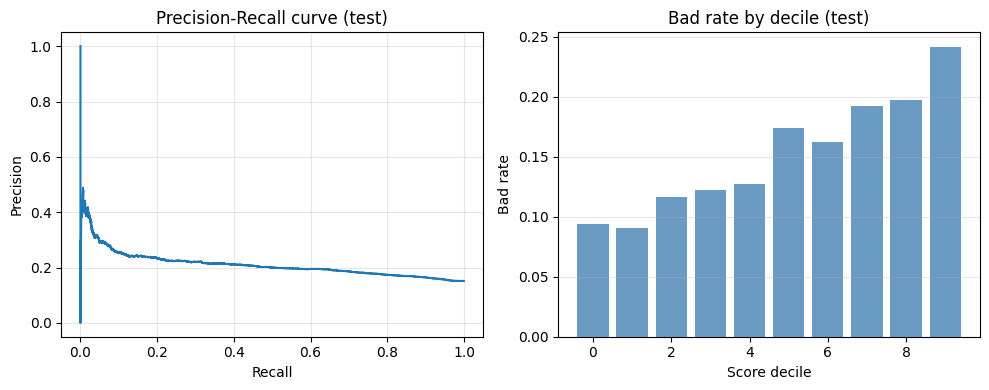


Subgroup performance (test):
  purpose_risk_code=0.0: n=729, AUC=0.604, KS=0.200
  purpose_risk_code=1.0: n=6527, AUC=0.598, KS=0.163
  purpose_risk_code=2.0: n=14465, AUC=0.602, KS=0.163
  home_ownership_risk_code=0.0: n=1616, AUC=0.602, KS=0.186
  home_ownership_risk_code=1.0: n=10158, AUC=0.622, KS=0.201
  home_ownership_risk_code=2.0: n=9947, AUC=0.583, KS=0.131


In [17]:
# Credit metrics on test set (out-of-time when time split is used)
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc

results_final_oot = None  # set below when X_test exists; used by 4b comparison table

def ks_statistic(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return np.max(np.abs(tpr - fpr))

def psi(scores_train, scores_test, n_bins=10):
    breakpoints = np.percentile(scores_train, np.linspace(0, 100, n_bins + 1))
    breakpoints[-1] += 1e-6
    def bin_pct(scores):
        pcts = np.diff(np.searchsorted(np.sort(scores), breakpoints)) / len(scores)
        return np.clip(pcts, 1e-6, 1)
    p_train = bin_pct(scores_train)
    p_test = bin_pct(scores_test)
    return np.sum((p_test - p_train) * np.log(p_test / p_train))

if "X_test" in dir() and X_test is not None and len(X_test) > 0:
    p_train = final_model.predict_proba(X_full)[:, 1]
    p_test = final_model.predict_proba(X_test_filled)[:, 1]
    auc_roc = roc_auc_score(y_test, p_test)
    gini = 2 * auc_roc - 1
    ks = ks_statistic(y_test, p_test)
    psi_val = psi(p_train, p_test)
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, p_test)
    auc_pr = auc(recall_curve, precision_curve)
    # Binary-class credit metrics including F1
    results_final_oot = eval_binary(y_test, p_test)
    print("Stacked model OOT: AUC-ROC = {:.4f}, F1 = {:.4f}, Gini = {:.4f}, KS = {:.4f}, PSI (train vs test) = {:.4f}, AUC-PR = {:.4f} (n_test={})".format(results_final_oot['auc_roc'], results_final_oot['f1'], gini, ks, psi_val, auc_pr, len(y_test)))

    # Bad rate by score decile (monotonicity)
    deciles = np.percentile(p_test, np.linspace(0, 100, 11))
    deciles[-1] += 1e-6
    bad_rates = []
    for i in range(10):
        mask = (p_test >= deciles[i]) & (p_test < deciles[i + 1])
        if mask.sum() > 0:
            bad_rates.append(y_test[mask].mean())
        else:
            bad_rates.append(np.nan)
    print("Bad rate by decile (low to high PD):", [round(b, 4) if not np.isnan(b) else b for b in bad_rates])
    if not np.any(np.isnan(bad_rates)):
        monotonic = all(bad_rates[i] <= bad_rates[i+1] + 1e-6 for i in range(len(bad_rates)-1))
        print("Monotonic (bad rate increases with decile):", monotonic)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(recall_curve, precision_curve)
    axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision"); axes[0].set_title("Precision-Recall curve (test)")
    axes[0].grid(True, alpha=0.3)
    axes[1].bar(range(10), bad_rates, color="steelblue", alpha=0.8)
    axes[1].set_xlabel("Score decile"); axes[1].set_ylabel("Bad rate"); axes[1].set_title("Bad rate by decile (test)")
    axes[1].grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

    # Performance by subgroup (purpose_risk_code, home_ownership_risk_code)
    if "purpose_risk_code" in X_test.columns and "home_ownership_risk_code" in X_test.columns:
        print("\nSubgroup performance (test):")
        for col in ["purpose_risk_code", "home_ownership_risk_code"]:
            for val in sorted(X_test[col].dropna().unique()):
                m = X_test[col] == val
                if m.sum() >= 50 and y_test[m].nunique() >= 2:
                    auc_s = roc_auc_score(y_test[m], p_test[m])
                    ks_s = ks_statistic(np.asarray(y_test[m]).ravel(), np.asarray(p_test[m]).ravel())
                    print(f"  {col}={val}: n={m.sum()}, AUC={auc_s:.3f}, KS={ks_s:.3f}")
else:
    print("No test set (X_test) available; run with time-based split from notebook 01.")

## 6. SHAP explainability

Summary plot, partial dependence for top features, and one SHAP waterfall for a high-PD (flagged) loan.

C:\Users\leemi\AppData\Local\Temp\ipykernel_9280\2203856521.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_val[: min(500, len(X_val))], feature_names=feature_names, show=False)


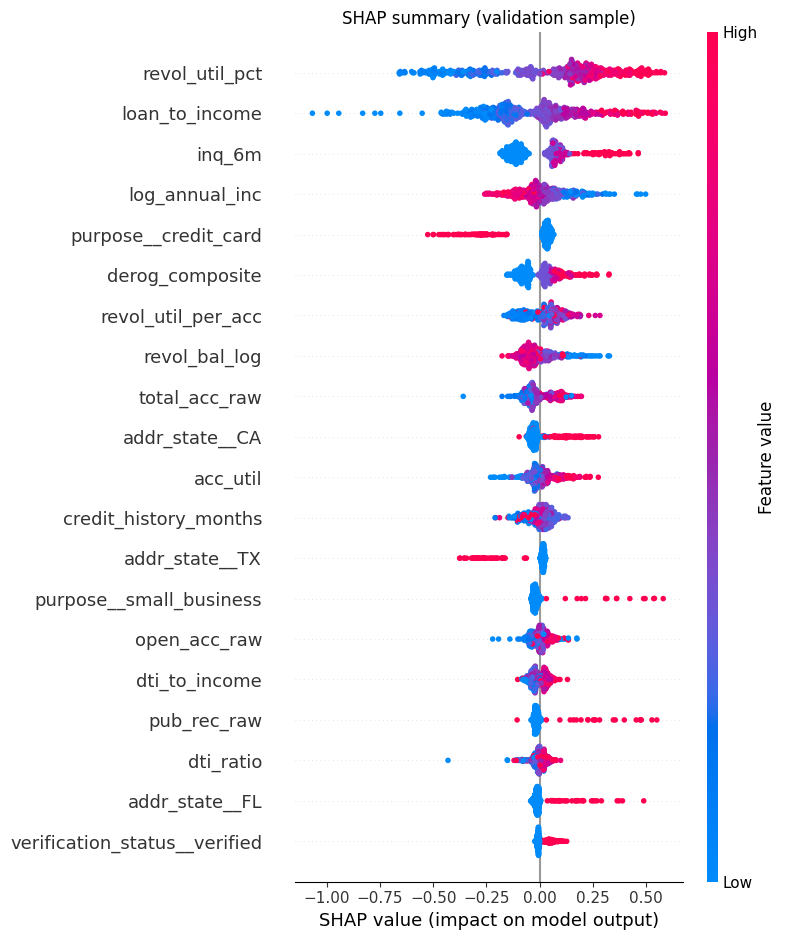

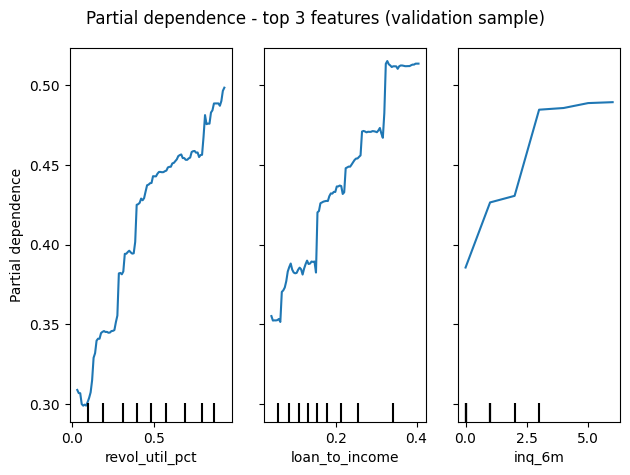

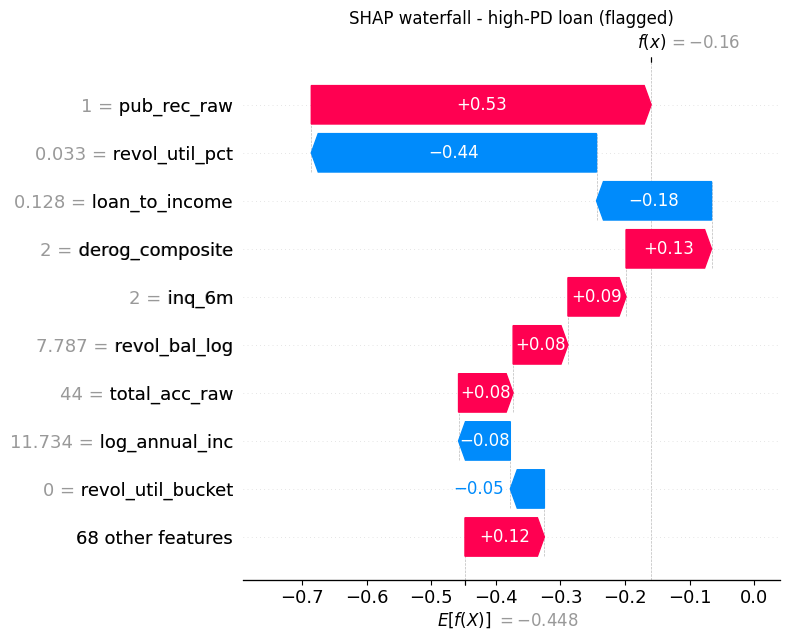

SHAP summary computed on n_val=11536 (SHAP subset up to 500/1000 as configured above)


In [18]:
# SHAP: use the underlying XGBoost if final_model is stacked
import shap
model_for_shap = final_model.xgb_model if hasattr(final_model, "xgb_model") else final_model
explainer = shap.TreeExplainer(model_for_shap, X_train[: min(2000, len(X_train))])
shap_values = explainer.shap_values(X_val[: min(500, len(X_val))])

shap.summary_plot(shap_values, X_val[: min(500, len(X_val))], feature_names=feature_names, show=False)
plt.title("SHAP summary (validation sample)")
plt.tight_layout()
plt.show()

# Partial dependence for top 3 features (by mean |SHAP|)
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[-3:][::-1]
top_names = [feature_names[i] for i in top_idx]
try:
    from sklearn.inspection import PartialDependenceDisplay
    X_val_sample = X_val[: min(1000, len(X_val))]
    PartialDependenceDisplay.from_estimator(model_for_shap, X_val_sample, top_names, kind="average")
    plt.suptitle("Partial dependence - top 3 features (validation sample)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("PDP skipped:", e)

# Waterfall for one high-PD (flagged) loan
idx_flagged = np.argmax(final_model.predict_proba(X_val)[:, 1])
shap_expl = explainer(X_val.iloc[[idx_flagged]])
try:
    shap.plots.waterfall(shap_expl[0], show=False)
except AttributeError:
    shap.waterfall_plot(shap_expl[0], show=False)
plt.title("SHAP waterfall - high-PD loan (flagged)")
plt.tight_layout()
plt.show()
print(f"SHAP summary computed on n_val={len(X_val)} (SHAP subset up to 500/1000 as configured above)")

## 7. Model card

**Dataset / cohort:** Lending Club LoanStats3a (origination-only features). Train: 2007-2015, Val: 2016, Test: 2017-2018 (out-of-time).

**Leakage exclusions:** No post-origination or outcome-related variables (e.g. grade, sub_grade, int_rate, total_pymnt, recoveries, last_pymnt_amnt, etc.) are used.

**Out-of-time validation:** Test set is strictly after training period to mimic deployment.

**Limitations:** US consumer loans only; performance may differ in other geographies or products. Default definition: Charged Off / Default / Late 31-120 days vs Fully Paid.

**Monitoring / retraining:** PSI thresholds: &lt; 0.1 stable, 0.1-0.25 monitor, &gt; 0.25 unstable (retrain). KS-stat drop &gt; 5 points vs baseline triggers review. Monitor PSI and AUC on recent cohorts.

**Top drivers:** See SHAP summary and PDPs above; document top 5 features and direction (e.g. higher DTI -> higher PD) in validation report.

**MAS FEAT:** Origination-time features only (FEAT-compliant where applicable). Bias testing across demographic proxies (e.g. by state, purpose) should be run where data permits; see subgroup performance above.

## 8. Save model for eval_runner

Persist the tuned model in the format expected by `credit_risk.models.pd_model.PDModel` (joblib with model, feature_names, params, metadata). Eval adapter uses `parse_query_to_features(..., use_no_leakage=True)` to match this feature set.

In [19]:
import joblib
import json

MODEL_DIR = ROOT / "models" / "pd"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Feature medians for HF eval (Phase 1: median fill instead of 0)
feature_medians = X_full.median().to_dict()
feature_medians = {k: float(v) if pd.notna(v) else 0.0 for k, v in feature_medians.items()}
with open(MODEL_DIR / "feature_medians.json", "w", encoding="utf-8") as f:
    json.dump(feature_medians, f, indent=2)

model_data = {
    "model": final_model,
    "feature_names": feature_names,
    "params": best_params,
    "metadata": {
        "trained_at": pd.Timestamp.now().isoformat(),
        "use_no_leakage": True,
        "n_features": len(feature_names),
        "n_train": len(X_full),
        "val_auc_roc": final_metrics["auc_roc"],
        "val_f1": final_metrics["f1"],
        "test_auc_roc": float(test_metrics["auc_roc"]) if "test_metrics" in dir() else None,
        "data_source": "LoanStats3a",
        "best_threshold": best_threshold_opt if "best_threshold_opt" in dir() else 0.5,
    },
}
path = MODEL_DIR / "pd_model_local_v2.pkl"  # v2 preferred by eval_runner; overwritten by joblib.dump
joblib.dump(model_data, path)
print(f"Saved to {path}")

Saved to c:\Users\leemi\OneDrive\Desktop\Job_search_2026\ocr-agentic-rag\models\pd\pd_model_local_v2.pkl


## 9. Download model to your PC (Colab only)

On **Google Colab**, run the cell below to download the saved model file to your computer. Then place `pd_model_local_v2.pkl` in your local repo under **`models/pd/`** so that `eval_runner.py` (e.g. overnight on your PC) can load it.

In [20]:
# Download trained model from Colab so you can put it in models/pd/ on your PC
try:
    from google.colab import files
    _in_colab = True
except ImportError:
    _in_colab = False
if _in_colab:
        pkl_path = ROOT / "models" / "pd" / "pd_model_local_v2.pkl"
        if pkl_path.exists():
            files.download(str(pkl_path))
            print("Download started: save pd_model_local_v2.pkl to your repo models/pd/ folder.")
        else:
            print("Model file not found. Run the Save model cell above first.")
else:
    print("Not on Colab. Model is already in", str(ROOT / "models" / "pd") + ".")


Not on Colab. Model is already in c:\Users\leemi\OneDrive\Desktop\Job_search_2026\ocr-agentic-rag\models\pd.


## 10. Run full evaluation (Colab or local)

**Where is ground truth?**  
- **Training** (notebook 01 + this notebook): uses **LoanStats3a.csv** -> engineered to `lendingclub_engineered.parquet`.  
- **Evaluation** (this section): uses the **LendingClub benchmark** from HuggingFace (**TheFinAI/lendingclub-benchmark**), which has query + gold labels. It is stored as **parquet** under `data/credit_risk_pd/LendingClub/{test,train,valid}/`. If you use a script like `data/generate_pq_first_5_rows.py` (or the repo's download script), it downloads from the Hub and can export parquet + first_5_rows for LendingClub.

On **Colab**, the cell below ensures the evaluation parquet exists (downloads from HF if needed), runs `eval_runner.py --category credit_risk_PD --dataset LendingClub` with the saved model, then displays the evaluation summary.

### Evaluation deliverables: per_sample JSON + QA txt

**Colab:** Download all `*_per_sample_*.json` files (all splits) and generate **Question-Answer** `.txt` files from them, then download those txt files.  
**Local:** Generate the same QA txt files and **save** them to `data/proof/credit_risk_pd/lendingclub/<split>/` (no download).

In [21]:
# Per-sample JSON + QA txt: Colab = download both; local = save txt to data/proof
import json
from pathlib import Path
PROOF_DIR = ROOT / "data" / "proof"
CATEGORY, DATASET = "credit_risk_pd", "LendingClub"
base = PROOF_DIR / CATEGORY.lower() / DATASET.lower()
per_sample_paths = sorted(base.rglob("*_samples.json")) if base.exists() else []

def _rows_to_qa_txt(rows):
    lines = []
    for i, row in enumerate(rows):
        if i > 0: lines.append("")
        lines.append("=" * 72)
        lines.append(f"sample_id: {row.get('sample_id', '')}")
        lines.append(f"split: {row.get('split', '')}")
        lines.append(f"ground_truth: {row.get('ground_truth', '')}")
        inp = row.get("input_text") or {}
        if isinstance(inp, dict) and inp.get("question"):
            lines.append("question: " + str(inp.get("question", "")))
        elif isinstance(inp, str): lines.append("input_text: " + inp)
        else: lines.append("input_text: " + json.dumps(inp, ensure_ascii=False))
        lines.append("-" * 72)
        pred = row.get("prediction") or ""
        lines.append("prediction:")
        lines.append(pred if isinstance(pred, str) else json.dumps(pred, ensure_ascii=False))
        if row.get("prediction_error"):
            lines.append("-" * 72)
            lines.append(f"prediction_error: {row.get('prediction_error')}")
        met = row.get("metrics") or {}
        if met:
            lines.append("-" * 72)
            lines.append("metrics: " + json.dumps(met, ensure_ascii=False))
        lines.append("=" * 72)
    return "\n".join(lines)

try:
    from google.colab import files as colab_files
    _in_colab = True
except ImportError:
    _in_colab = False

for per_sample_path in per_sample_paths:
    try:
        with open(per_sample_path, "r", encoding="utf-8") as f:
            rows = json.load(f)
    except Exception:
        continue
    if not isinstance(rows, list) or not rows:
        continue
    stem = per_sample_path.stem
    base_name = stem.replace("_samples", "") if stem.endswith("_samples") else stem
    txt_name = f"{base_name}_predictions.txt"
    txt_content = _rows_to_qa_txt(rows)
    out_path = per_sample_path.parent / txt_name
    if _in_colab:
        colab_files.download(str(per_sample_path))
        tmp_txt = Path(txt_name)
        tmp_txt.write_text(txt_content, encoding="utf-8")
        colab_files.download(str(tmp_txt))
    else:
        out_path.write_text(txt_content, encoding="utf-8")
        print(f"[export] {out_path}")

if _in_colab and per_sample_paths:
    print("Colab: downloads started for per_sample JSON + predictions txt.")
elif not per_sample_paths:
    print("No per_sample JSONs found. Run eval cell above first.")

[export] c:\Users\leemi\OneDrive\Desktop\Job_search_2026\ocr-agentic-rag\data\proof\credit_risk_pd\lendingclub\test\lendingclub_test_predictions.txt
[export] c:\Users\leemi\OneDrive\Desktop\Job_search_2026\ocr-agentic-rag\data\proof\credit_risk_pd\lendingclub\train\lendingclub_train_predictions.txt
[export] c:\Users\leemi\OneDrive\Desktop\Job_search_2026\ocr-agentic-rag\data\proof\credit_risk_pd\lendingclub\valid\lendingclub_valid_predictions.txt


In [22]:
# Ensure LendingClub evaluation data exists (parquet under test/train/valid); then run eval and show summary
import json
import subprocess

LC_BASE = ROOT / "data" / "credit_risk_pd" / "LendingClub"
PROOF_PD = ROOT / "data" / "proof" / "credit_risk_pd"

def _parquet_exists():
    for split in ("test", "train", "valid"):
        folder = LC_BASE / split
        if not folder.exists():
            return False
        if not list(folder.glob("*.parquet")):
            return False
    return True

if not _parquet_exists():
    print("LendingClub evaluation parquet not found. Downloading from HuggingFace (TheFinAI/lendingclub-benchmark)...")
    try:
        from datasets import load_dataset
        ds = load_dataset("TheFinAI/lendingclub-benchmark")
        split_map = {"train": "train", "test": "test", "validation": "valid"}
        for hf_split, folder_name in split_map.items():
            if hf_split not in ds:
                continue
            out_dir = LC_BASE / folder_name
            out_dir.mkdir(parents=True, exist_ok=True)
            path = out_dir / "data-00000-of-00001.parquet"
            ds[hf_split].to_parquet(path)
            print(f"  Wrote {path} ({len(ds[hf_split])} rows)")
        print("Done.")
    except Exception as e:
        print("Download failed:", e)
else:
    print("LendingClub evaluation data found.")

# Run eval_runner for credit_risk_PD (uses saved model at models/pd/pd_model_local_v2.pkl)
# No need to re-run Optuna: the loader fix is in credit_risk/models/pd_model.py.
# Use --max_split for quick run; set to None to re-score ALL samples and fix proof files.
MAX_SAMPLES_PER_SPLIT = 100  # set to None for full eval (fixes all samples in data/proof/credit_risk_pd)
cmd = [sys.executable, str(ROOT / "eval_runner.py"), "--category", "credit_risk_PD", "--dataset", "LendingClub"]
if MAX_SAMPLES_PER_SPLIT is not None:
    cmd.extend(["--max_split", str(MAX_SAMPLES_PER_SPLIT)])
print("\nRunning:", " ".join(cmd))
result = subprocess.run(cmd, cwd=str(ROOT), capture_output=True, text=True)
if result.stdout:
    print(result.stdout)
if result.returncode != 0:
    print("eval_runner stderr:", result.stderr[:2000] if result.stderr else "(none)")
else:
    proof_dir = ROOT / "data" / "proof" / "credit_risk_pd" / "lendingclub"
    print("Eval completed.", f"Proof dir exists: {proof_dir.exists()}" if proof_dir.exists() else "(no proof dir yet)")

LendingClub evaluation data found.

Running: c:\Users\leemi\AppData\Local\Programs\Python\Python311\python.exe c:\Users\leemi\OneDrive\Desktop\Job_search_2026\ocr-agentic-rag\eval_runner.py --category credit_risk_PD --dataset LendingClub --max_split 100

=== CATEGORY: CREDIT_RISK_PD ===
Updated data\proof\SUMMARY.md

Eval completed. Proof dir exists: True


In [23]:
# Display evaluation summary from proof outputs
summary_shown = False
# Dataset-level weighted average (LendingClub)
weighted_path = PROOF_PD / "lendingclub" / "lendingclub_avg.json"
if weighted_path.exists():
    with open(weighted_path, "r", encoding="utf-8") as f:
        w = json.load(f)
    print("=== PD evaluation summary (LendingClub benchmark) ===\n")
    print("Dataset weighted average:")
    for k, v in sorted(w.items()):
        if isinstance(v, (int, float)):
            print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")
        else:
            print(f"  {k}: {v}")
    summary_shown = True
# Per-split averages
for split_dir in (PROOF_PD / "lendingclub").iterdir() if (PROOF_PD / "lendingclub").exists() else []:
    if not split_dir.is_dir():
        continue
    avg_path = split_dir / "lendingclub_{}_avg.json".format(split_dir.name)
    if avg_path.exists():
        with open(avg_path, "r", encoding="utf-8") as f:
            s = json.load(f)
        auc = s.get("auc_roc_mean")
        f1 = s.get("f1_mean")
        n = s.get("sample_count", 0)
        auc_s = f"{auc:.4f}" if isinstance(auc, (int, float)) else str(auc)
        f1_s = f"{f1:.4f}" if isinstance(f1, (int, float)) else str(f1)
        print(f"\nSplit '{split_dir.name}' avg: auc_roc={auc_s}  f1={f1_s}  n={n}")
        summary_shown = True
# Category-level (credit_risk_pd)
cat_path = ROOT / "data" / "proof" / "credit_risk_pd_avg.json"
if cat_path.exists():
    with open(cat_path, "r", encoding="utf-8") as f:
        c = json.load(f)
    # Short summary so AUC and n are visible even if JSON is truncated in the notebook UI
    w = c.get("weighted_metrics") or {}
    if "auc_roc_mean" in w:
        print(f"\nCategory (credit_risk_pd) weighted avg (summary): auc_roc_mean={w['auc_roc_mean']:.4f} n={c.get('sample_count')}")
    else:
        print(f"\nCategory (credit_risk_pd) weighted avg (summary): n={c.get('sample_count')}")
    print("Category (credit_risk_pd) weighted avg:", json.dumps(c, indent=2))
    summary_shown = True
if not summary_shown:
    print("No evaluation summary files found. Run the cell above to run eval_runner and generate proofs.")

=== PD evaluation summary (LendingClub benchmark) ===

Dataset weighted average:
  dataset: LendingClub
  gt_override_count: 0
  sample_count: 13453
  splits: ['test', 'train', 'valid']
  splits_breakdown: [{'split': 'test', 'sample_count': 2691, 'metrics': {'auc_roc_mean': 0.6015111823932995, 'f1_mean': 0.06620209059233449, 'precision_mean': 0.3275862068965517, 'recall_mean': 0.03682170542635659}, 'gt_override_count': 0}, {'split': 'train', 'sample_count': 9417, 'metrics': {'auc_roc_mean': 0.6033617058641518, 'f1_mean': 0.08944213923467036, 'precision_mean': 0.377431906614786, 'recall_mean': 0.05073221757322176}, 'gt_override_count': 0}, {'split': 'valid', 'sample_count': 1345, 'metrics': {'auc_roc_mean': 0.5957439221810973, 'f1_mean': 0.06920415224913495, 'precision_mean': 0.3225806451612903, 'recall_mean': 0.03875968992248062}, 'gt_override_count': 0}]
  timestamp: 2026-03-14T16:51:30.944514+08:00
  weighted_metrics: {'auc_roc_mean': 0.6022299376552934, 'f1_mean': 0.0827700911121645

### Industry comparison and how to improve

- **Industry benchmarks (LendingClub / default prediction):** Typical reported AUC-ROC is **0.75-0.85**; strong benchmarks sit around **0.80-0.82**. Your **validation AUC (~0.68)** is below that, so there is room to improve.
- **Why AUC can show NaN on eval:** If a split has only one class (e.g. all "fully paid"), AUC is undefined; the eval pipeline now reports **0.5** instead of NaN for that split and in weighted averages.
- **Levers to try:** (1) **Use GPU on Colab** (Runtime -> Change runtime type -> T4 GPU) so tuning runs faster and you can try more trials or a wider search. (2) Widen **n_estimators** (e.g. 150-500) and lower **learning_rate** min (e.g. 0.01) in the Optuna cell. (3) Keep **stacking** (XGB + LightGBM) and **optimal threshold** (Section 4) for better F1. (4) Re-run **eval_runner** after fixes to get valid AUC in the benchmark summary.


### Training report (copy for feedback)

Run the cell below after tuning and saving. **Copy the block between the dashed lines** and paste it into chat so the assistant can suggest hyperparameter or training improvements for the next run.

In [24]:
# Key metrics report for iterative tuning (copy the output below the dashes)
try:
    _te = tune_elapsed
except NameError:
    _te = None
_report = [
    "--- PD XGBoost training report (copy for feedback) ---",
    "env: colab={} | gpu_used={} | optuna_n_jobs={}".format(
        IN_COLAB if "IN_COLAB" in dir() else False,
        USE_GPU,
        OPTUNA_N_JOBS if "OPTUNA_N_JOBS" in dir() else 1,
    ),
    "data: n_train={} n_val={} n_features={}".format(
        len(X_train), len(X_val), X_train.shape[1],
    ),
    "tuning: n_trials={} n_splits={}".format(
        N_TRIALS if "N_TRIALS" in dir() else 50,
        N_SPLITS if "N_SPLITS" in dir() else 5,
    ),
]
if _te is not None and "N_TRIALS" in dir():
    _report.append("timing: total_tune_sec={:.1f} sec_per_trial={:.1f}".format(_te, _te / max(N_TRIALS, 1)))
else:
    _report.append("timing: (not recorded)")
_report.extend([
    "best_cv_auc: {:.4f}".format(float(study.best_value)),
    "val_metrics: auc_roc={:.4f} f1={:.4f} precision={:.4f} recall={:.4f}".format(
        final_metrics["auc_roc"], final_metrics["f1"],
        final_metrics["precision"], final_metrics["recall"],
    ),
    "best_params: " + " | ".join("{}={}".format(k, v) for k, v in best_params.items()),
    "---",
])
print("\n".join(_report))

--- PD XGBoost training report (copy for feedback) ---
env: colab=False | gpu_used=False | optuna_n_jobs=6
data: n_train=6529 n_val=11536 n_features=77
tuning: n_trials=50 n_splits=5
timing: total_tune_sec=290.9 sec_per_trial=5.8
best_cv_auc: 0.8248
val_metrics: auc_roc=1.0000 f1=0.9963 precision=0.9953 recall=0.9973
best_params: max_depth=6 | learning_rate=0.014993029606520929 | n_estimators=399 | min_child_weight=5 | subsample=0.8684234161481916 | colsample_bytree=0.838189942683847 | reg_alpha=0.2621362239319259 | reg_lambda=0.37793010204829053 | objective=binary:logistic | scale_pos_weight=6.3690744920993225 | eval_metric=auc | random_state=42 | tree_method=hist
---


## 11. Colab: Download report (cell outputs)

**Model deliverable:** The **model snapshot** is the `.pkl` file (`pd_model_local_v2.pkl`) from the Save cell â€” download that on Colab if needed.

On **Google Colab only**, the cell below builds an **overall report** of key cell outputs and **downloads** it (no saving to `models/` on local).

In [25]:
# Report of key cell outputs: Colab = build + download only; local = no write to models/
report_lines = ["PD XGBoost training - overall report", "=" * 60, "",]
if "final_metrics" in dir() and final_metrics is not None:
    report_lines.append("Validation metrics:")
    for k, v in final_metrics.items():
        report_lines.append(f"  {k}: {v}")
    report_lines.append(f"  n_val: {len(y_val)}")
    report_lines.append("")
if "results_stack_oot" in dir() and results_stack_oot is not None:
    report_lines.append("Stacked model OOT metrics:")
    report_lines.append(f"  auc_roc: {round(results_stack_oot['auc_roc'], 4)}  f1: {round(results_stack_oot['f1'], 4)}")
    report_lines.append(f"  n_test: {len(y_test)}")
    report_lines.append("")
if "best_params" in dir() and best_params is not None:
    report_lines.append("Best Optuna params:")
    for k, v in best_params.items():
        report_lines.append(f"  {k}: {v}")
    report_lines.append("")
if "best_threshold_opt" in dir():
    report_lines.append(f"Optimal threshold (max F1): {best_threshold_opt}")
    report_lines.append("")
report_lines.extend(["Data: LoanStats3a -> lendingclub_engineered.parquet", "Model snapshot: pd_model_local_v2.pkl (download from Save cell on Colab)", ""])
report_txt = "\n".join(report_lines)

try:
    from google.colab import files
    from pathlib import Path
    report_path = Path("report_pd_xgboost.txt")
    report_path.write_text(report_txt, encoding="utf-8")
    files.download(str(report_path))
    print("Report download started. Paste into repo or keep for records.")
except ImportError:
    print("Local run: report not saved to models/ folder.")
    print(report_txt[:800] + ("..." if len(report_txt) > 800 else ""))

Local run: report not saved to models/ folder.
PD XGBoost training - overall report

Validation metrics:
  auc_roc: 0.9999833365266081
  f1: 0.9963050050386295
  precision: 0.9953020134228188
  recall: 0.9973100201748487
  n_val: 11536

Best Optuna params:
  max_depth: 6
  learning_rate: 0.014993029606520929
  n_estimators: 399
  min_child_weight: 5
  subsample: 0.8684234161481916
  colsample_bytree: 0.838189942683847
  reg_alpha: 0.2621362239319259
  reg_lambda: 0.37793010204829053
  objective: binary:logistic
  scale_pos_weight: 6.3690744920993225
  eval_metric: auc
  random_state: 42
  tree_method: hist

Optimal threshold (max F1): 0.54

Data: LoanStats3a -> lendingclub_engineered.parquet
Model snapshot: pd_model_local_v2.pkl (download from Save cell on Colab)



## 12. Summary

- Trained XGBoost (and Random Forest) on LoanStats3a-derived features; tuned XGBoost via **Optuna** (stratified 5-fold CV, early stopping) to maximize AUC-ROC.
- Final model refit on full train+val and saved as `models/pd/pd_model_local_v2.pkl`. For **overnight sample-by-sample evaluation** on a CPU-only machine (e.g. i5-11500, 16GB), run from repo root: `python eval_runner.py --category credit_risk_PD`. Proof JSONs are written under `data/proof/credit_risk_pd/` for comparison with quantum models later.